# Trabajo Práctico 2 - Grupo 02

### Modelo BETO — Entrega N9

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

**Modelo:** `dccuchile/bert-base-spanish-wwm-cased` (BETO)

**Dataset:** original_51k

**Hiperparámetros:** `lr=1e-05` | `epochs=5` | `max_length=128` | `batch_size=32`

**Justificación de cambios respecto a N8 (xlm-roberta-large, F1=0.7325):**
- Se reemplaza `xlm-roberta-large` por BETO (`dccuchile/bert-base-spanish-wwm-cased`). BETO fue pre-entrenado exclusivamente sobre texto en español (Wikipedia + OpenSubtitles + OPUS), lo que le da ventaja sobre un modelo multilingüe para esta tarea.
- Se reduce el learning rate de `2e-5` a `1e-5`. Un LR más bajo produce actualizaciones más conservadoras, lo que reduce el riesgo de catastrophic forgetting sobre los pesos pre-entrenados en español.
- Se aumentan las épocas de 3 a 5. Con un LR más bajo el modelo converge más lento, por lo que necesita más épocas para alcanzar su rendimiento óptimo. El EarlyStoppingCallback con patience=2 corta automáticamente si no hay mejora.
- Se sube el batch size de 16 a 32. BETO base (~110M params) es más liviano que xlm-roberta-large (~560M), liberando VRAM para un batch mayor, lo que estabiliza los gradientes.

## 1. Instalación de dependencias

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install transformers datasets accelerate
!pip install scikit-learn joblib
!pip install pandas numpy
!pip install matplotlib seaborn

Looking in indexes: https://download.pytorch.org/whl/cu124
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 9.7 MB/s e

## 2. Imports y configuración

In [2]:
import sys
sys.path.insert(0, "/kaggle/input/datasets/maylennieves/common")

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from common.data_utils import get_split, SEED
from common.preprocessing import clean_minimal
from common.evaluation import evaluate

np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME  = "dccuchile/bert-base-spanish-wwm-cased"
MAX_LENGTH  = 128
BATCH_SIZE  = 32
NUM_EPOCHS  = 5
LR          = 1e-05
CLASS_NAMES = ["negativa", "neutra", "positiva"]

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Modelo: {MODEL_NAME}")
print(f"Config: lr={LR} | epochs={NUM_EPOCHS} | max_length={MAX_LENGTH} | batch={BATCH_SIZE}")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Modelo: dccuchile/bert-base-spanish-wwm-cased
Config: lr=1e-05 | epochs=5 | max_length=128 | batch=32


## 3. Carga de datos

In [3]:
train_df = pd.read_csv("/kaggle/input/datasets/maylennieves/dataset/train.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/maylennieves/dataset/test.csv")

print(f"Train: {len(train_df):,} filas")
print(f"Distribución:\n{train_df['label'].value_counts().sort_index()}")
print(f"\nProporciones:\n{train_df['label'].value_counts(normalize=True).sort_index().round(3)}")

X_train_raw, X_val_raw, y_train, y_val = get_split(train_df)

print("\nAplicando clean_minimal...")
X_train = np.array([clean_minimal(t) for t in X_train_raw])
X_val   = np.array([clean_minimal(t) for t in X_val_raw])
X_test  = np.array([clean_minimal(t) for t in test_df["text"].values])
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train: 51,000 filas
Distribución:
label
0    20400
1    10200
2    20400
Name: count, dtype: int64

Proporciones:
label
0    0.4
1    0.2
2    0.4
Name: proportion, dtype: float64

Aplicando clean_minimal...
Train: 40,800 | Val: 10,200 | Test: 8,500


## 4. Dataset y tokenización

BETO usa **WordPiece** con tokens especiales `[CLS]` y `[SEP]`, igual que BERT.
Su vocabulario de 31.000 tokens fue construido exclusivamente sobre texto en español,
por lo que representa mejor la morfología del idioma que un tokenizador multilingüe.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Ejemplo de tokenización con BETO:")
for t in ["No funciona bien, muy decepcionante.", "Excelente producto, lo recomiendo.",
          "Llegó en perfecto estado pero la calidad es regular."]:
    print(f"  '{t}'")
    print(f"   → {tokenizer.tokenize(t)}\n")

class ResenasDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

print("Tokenizando datasets...")
train_dataset = ResenasDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = ResenasDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = ResenasDataset(X_test,  None,    tokenizer, MAX_LENGTH)
print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Ejemplo de tokenización con BETO:
  'No funciona bien, muy decepcionante.'
   → ['No', 'funciona', 'bien', ',', 'muy', 'decepcion', '##ante', '.']

  'Excelente producto, lo recomiendo.'
   → ['Excelente', 'producto', ',', 'lo', 'recomiendo', '.']

  'Llegó en perfecto estado pero la calidad es regular.'
   → ['Llegó', 'en', 'perfecto', 'estado', 'pero', 'la', 'calidad', 'es', 'regular', '.']

Tokenizando datasets...
Train: 40,800 | Val: 10,200 | Test: 8,500


## 5. Modelo y métricas

`AutoModelForSequenceClassification` carga BETO y agrega una capa lineal (768 → 3 clases)
sobre el token `[CLS]`. Se fine-tunean todos los parámetros del modelo.

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_neg":   float(f1_per[0]),
        "f1_neu":   float(f1_per[1]),
        "f1_pos":   float(f1_per[2]),
    }

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Parámetros totales:     109,853,187
Parámetros entrenables: 109,853,187


## 6. Fine-tuning

**Justificación de hiperparámetros:**
- `lr=1e-5`: más conservador que el `2e-5` de N8, reduce el riesgo de destruir los pesos pre-entrenados en español.
- `epochs=5`: con LR más bajo el modelo converge más lento; el EarlyStoppingCallback corta si no hay mejora en 2 épocas consecutivas.
- `batch_size=32`: BETO es más liviano que xlm-roberta-large, permite batch más grande y gradientes más estables.
- `warmup_ratio=0.1`: primeros 10% de pasos con LR creciente, evita actualizaciones bruscas al inicio.
- `weight_decay=0.01`: regularización L2 para reducir overfitting.
- `fp16=True`: precisión mixta, más rápido y menos VRAM.

In [6]:
OUTPUT_DIR = Path("models/red_neuronal_beto_v9_lr1e5_ep5")

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Iniciando fine-tuning de BETO...")
print(f"  Dataset:    original_51k ({len(X_train):,} train | {len(X_val):,} val)")
print(f"  LR:         {LR}")
print(f"  Epochs:     {NUM_EPOCHS} (early stopping patience=2)")
print(f"  Max length: {MAX_LENGTH}")
print(f"  Batch:      {BATCH_SIZE}")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Iniciando fine-tuning de BETO...
  Dataset:    original_51k (40,800 train | 10,200 val)
  LR:         1e-05
  Epochs:     5 (early stopping patience=2)
  Max length: 128
  Batch:      32


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Neg,F1 Neu,F1 Pos
1,1.168106,1.118540,0.684525,0.827312,0.370278,0.855986
2,1.076707,1.094187,0.713735,0.832720,0.447433,0.861051
3,0.951927,1.116059,0.718336,0.826754,0.466084,0.862169
4,0.823841,1.178922,0.707087,0.828016,0.430665,0.862579
5,0.783514,1.188010,0.716996,0.822448,0.465140,0.863401


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3190, training_loss=1.0045527275826864, metrics={'train_runtime': 2716.8929, 'train_samples_per_second': 75.086, 'train_steps_per_second': 1.174, 'total_flos': 1.3418784304128e+16, 'train_loss': 1.0045527275826864, 'epoch': 5.0})

## 7. Evaluación en validación

In [7]:
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

evaluate(
    "red_neuronal_beto_v9_lr1e5_ep5",
    y_val,
    y_pred,
    hyperparams={
        "model":      MODEL_NAME,
        "epochs":     NUM_EPOCHS,
        "lr":         LR,
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "dataset":    "original_51k",
    }
)

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



=== red_neuronal_beto_v9_lr1e5_ep5 ===
Hiperparámetros: {'model': 'dccuchile/bert-base-spanish-wwm-cased', 'epochs': 5, 'lr': 1e-05, 'max_length': 128, 'batch_size': 32, 'dataset': 'original_51k'}

F1-macro:  0.7184
Precision: 0.7200
Recall:    0.7178
Accuracy:  0.7725

              precision    recall  f1-score   support

    negativa     0.8220    0.8319    0.8269      4080
      neutra     0.4903    0.4446    0.4663      2040
    positiva     0.8477    0.8770    0.8621      4080

    accuracy                         0.7725     10200
   macro avg     0.7200    0.7178    0.7184     10200
weighted avg     0.7659    0.7725    0.7688     10200

Matriz de confusión (filas=real, cols=predicho):
          negativa  neutra  positiva
negativa      3394     570       116
neutra         606     907       527
positiva       129     373      3578


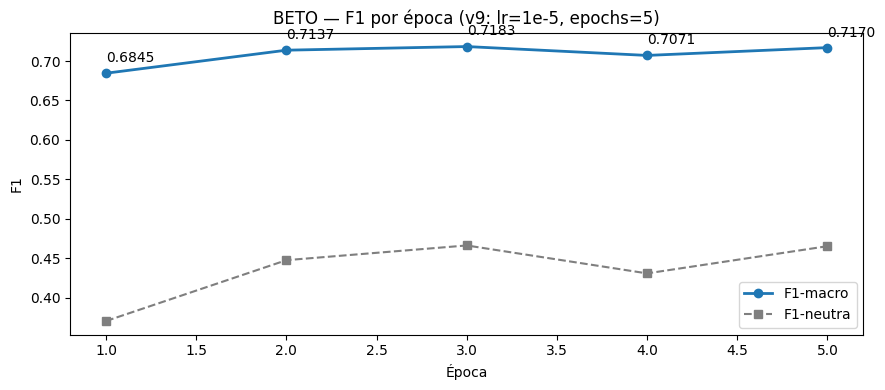

In [8]:
import matplotlib.pyplot as plt

history  = trainer.state.log_history
eval_f1  = [(x["epoch"], x["eval_f1_macro"]) for x in history if "eval_f1_macro" in x]
eval_neu = [(x["epoch"], x["eval_f1_neu"])   for x in history if "eval_f1_neu"   in x]

fig, ax = plt.subplots(figsize=(9, 4))
if eval_f1:
    epochs, f1s = zip(*eval_f1)
    ax.plot(epochs, f1s, marker="o", label="F1-macro", color="#1f77b4", linewidth=2)
    for e, f in zip(epochs, f1s):
        ax.annotate(f"{f:.4f}", (e, f), textcoords="offset points", xytext=(0, 8))
if eval_neu:
    epochs, f1s = zip(*eval_neu)
    ax.plot(epochs, f1s, marker="s", label="F1-neutra", color="#7f7f7f", linestyle="--")

ax.set_xlabel("Época")
ax.set_ylabel("F1")
ax.set_title("BETO — F1 por época (v9: lr=1e-5, epochs=5)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Guardado del modelo

In [9]:
SAVE_DIR = Path("models/red_neuronal_beto_v9_lr1e5_ep5_final")
trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))
print(f"Modelo guardado en {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en models/red_neuronal_beto_v9_lr1e5_ep5_final


## 9. Submission a Kaggle

In [10]:
Path("submissions").mkdir(exist_ok=True)

preds_test  = trainer.predict(test_dataset)
y_test_pred = np.argmax(preds_test.predictions, axis=1)

sub = pd.DataFrame({"id": test_df["id"].values, "label": y_test_pred.astype(int)})
sub.to_csv("submissions/submission_red_neuronal_beto_v9_lr1e5_ep5.csv", index=False)

dist = sub["label"].value_counts(normalize=True).sort_index()
print(f"Guardado: submissions/submission_red_neuronal_beto_v9_lr1e5_ep5.csv  ({len(sub)} predicciones)")
print(f"Distribución: {', '.join(f'clase {k}: {v:.1%}' for k, v in dist.items())}")

Guardado: submissions/submission_red_neuronal_beto_v9_lr1e5_ep5.csv  (8500 predicciones)
Distribución: clase 0: 40.6%, clase 1: 18.8%, clase 2: 40.5%
